# PS-S5E12: XGBoost

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [21]:
%load_ext autoreload
%autoreload 2
    
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory
from model_visualizer import ModelVisualizer
from experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'diagnosed_diabetes'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0   

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500 

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'clinical_indices',
    'interactions',
    'ratios',
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 25
New Feature Count: 36
   age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   31                             1                                  45   
1   50                             2                                  73   
2   32                             3                                 158   
3   54                             3                                  77   
4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  sys

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

In [7]:
n_jobs = 1 if USE_GPU else -1

# Convert object columns to 'category' dtype
X_rfe = X.copy()

# Identify string/object columns
cat_cols = X_rfe.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_rfe[cat_cols] = oe.fit_transform(X_rfe[cat_cols])
    
    # Ensure they are cast to integer type for XGBoost
    # We cast to 'category' type so XGBoost knows to treat them as discrete
    for col in cat_cols:
        X_rfe[col] = X_rfe[col].astype('category')
        
if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')
    
    # Use a "stfe" set of parameters
    rfe_params = {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'max_depth': 6,          # Standard starting depth
        'colsample_bytree': 0.8, # Allow it to see most features
        'reg_alpha': 0.1,        # Light regularization only
        'device': 'cuda',
        'tree_method': 'hist',
        'enable_categorical': True
    }
    
    # 'gpu_hist' is removed. Now we use 'hist' + device='cuda'
    if USE_GPU:
        rfe_params['device'] = 'cuda'
    else:
        rfe_params['device'] = 'cpu'
    
    # Setup Model with Best Params
    # We use the exact same params that found the signal in the noise
    clf = xgb.XGBClassifier(**rfe_params)

    # Initialize RFECV
    # step=1: remove 1 feature at a time (most precise)
    # min_features_to_select=10: Don't go below 10 features
    rfecv = RFECV(
        estimator=clf,
        step=0.05,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring='roc_auc',
        min_features_to_select=10,
        n_jobs=n_jobs,
        verbose=0
    )
    
    print('Running Recursive Feature Elimination (this may take 2-3 minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross validation score (AUC)')
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using all columns as optimal features.')
    optimal_cols = X_rfe.columns
    
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features:
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level_ord', 'income_level_ord', 'pulse_pressure', 'mean_arterial_pressure', 'non_hdl_cholesterol', 'vai_proxy', 'lap_proxy', 'age_bmi_interaction', 'sedentary_ratio', 'cholesterol_risk_ratio', 'bp_ratio', 'whr_bmi_product']


In [8]:
def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 8000,              # Give it room to run, let early stopping cut it
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.03, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        
        # Regularization (Expanded ranges)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),  # L1 Reg
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # L2 Reg
        'gamma': trial.suggest_float('gamma',1e-8, 1.0, log=True),
        
        # Tree Structure & Imbalance
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        # Helps with class imbalance (approx ratio of negatives/positives)
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 2.0),  
        
        # Boilerplate
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'enable_categorical': True,  # Native categorical support
        'random_state': seed,
        'early_stopping_rounds': 50,
        'n_jobs': n_jobs
    }

    # Ensure optimal_cols is a standard list for filtering
    # (Handling cases where it might be a pandas Index or numpy array)
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    # Fast CV (3 Folds is enough for tuning)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    scores = []

    for train_idx, val_idx in skf.split(training_df, y):
        X_train_fold, X_val_fold = training_df.iloc[train_idx], training_df.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Create a FeatureFactory for this fold's data
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Filter Columns using 'optimal_cols'
        # We take the intersection to be safe (in case FE dropped a col for some reason)
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]
        
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
    
        if cat_cols:
            # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
            oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_train_trans[cat_cols] = oe.fit_transform(X_train_trans[cat_cols])
            X_val_trans[cat_cols] = oe.transform(X_val_trans[cat_cols])
            
            # Ensure they are cast to integer type for XGBoost
            # We cast to 'category' type so XGBoost knows to treat them as discrete
            for col in cat_cols:
                X_train_trans[col] = X_train_trans[col].astype('category')
                X_val_trans[col] = X_val_trans[col].astype('category')
            
        # Create XGBoost internal DMatrix for efficiency
        # (Optional, but good practice. passing dataframes directly is fine too)
        model = xgb.XGBClassifier(**param)
        
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            verbose=False
        )
        
        # Predict
        preds = model.predict_proba(X_val_trans)[:, 1]
        score = roc_auc_score(y_val_fold, preds)
        scores.append(score)

    return np.mean(scores)

if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='xgb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=40, show_progress_bar=True)

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.02439360295107937,
        'max_depth': 3,
        'min_child_weight': 3,
        'subsample': 0.9045225709226784,
        'colsample_bytree': 0.5406853248448557,
        'reg_alpha': 3.210592704435145,
        'reg_lambda': 1.0144816172456135,
        'gamma': 1.8754577975798167e-07,
        'grow_policy': 'depthwise',
        'scale_pos_weight': 1.1751264448135443
    }

[I 2025-12-08 15:19:02,310] A new study created in memory with name: xgb_diabetes_prediction_optuna


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-08 15:20:54,050] Trial 0 finished with value: 0.7258098482643515 and parameters: {'learning_rate': 0.018894820495061786, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.838563141577915, 'colsample_bytree': 0.6389391005441778, 'reg_alpha': 1.1448758024911176, 'reg_lambda': 9.746437376742904, 'gamma': 0.002081567336598265, 'grow_policy': 'depthwise', 'scale_pos_weight': 1.5970798866232845}. Best is trial 0 with value: 0.7258098482643515.
[I 2025-12-08 15:23:07,569] Trial 1 finished with value: 0.7247693096598722 and parameters: {'learning_rate': 0.012633090551131956, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.5084148367473084, 'colsample_bytree': 0.8558141006136075, 'reg_alpha': 0.35382830316192654, 'reg_lambda': 0.05924906068160358, 'gamma': 0.0001281654716366879, 'grow_policy': 'lossguide', 'scale_pos_weight': 1.034499227407168}. Best is trial 0 with value: 0.7258098482643515.
[I 2025-12-08 15:25:31,069] Trial 2 finished with value: 0.7253213506009107 and p

## Model Training

In [9]:
# Cross-Validation Training Loop

xgb_tuned_params = {
    **best_params,
    'n_estimators': 8000,    # High iterations have been observed; giving it room
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': n_jobs,
    'random_state': seed,
    'early_stopping_rounds': 50,
    'tree_method': 'gpu_hist' if USE_GPU else None,
    'enable_categorical': True,
}

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(X))     # Out-of-Fold predictions (for blending later)
test_preds = np.zeros(len(test_df)) # Average test predictions

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f'\nStarting XGBoost Training ({n_folds} Folds)...')

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    X_train_fold, y_train_fold = training_df.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = training_df.iloc[val_idx], y.iloc[val_idx]

    # Create a FeatureFactory for this fold's data
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    x_train_trans = X_train_trans[optimal_cols]
    X_val_trans = X_val_trans[optimal_cols]
    X_test_trans = X_test_trans[optimal_cols]
    
    # Filter Columns using 'optimal_cols'
    # We take the intersection to be safe (in case FE dropped a col for some reason)
    final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
    
    X_train_trans = X_train_trans[final_cols]
    X_val_trans = X_val_trans[final_cols]
    X_test_trans = X_test_trans[final_cols]
    
    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

    if cat_cols:
        # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train_trans[cat_cols] = oe.fit_transform(X_train_trans[cat_cols])
        X_val_trans[cat_cols] = oe.transform(X_val_trans[cat_cols])
        X_test_trans[cat_cols] = oe.transform(X_test_trans[cat_cols])

        # Ensure they are cast to integer type for XGBoost
        # We cast to 'category' type so XGBoost knows to treat them as discrete
        for col in cat_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col] = X_val_trans[col].astype('category')
            X_test_trans[col] = X_test_trans[col].astype('category')

    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = xgb.XGBClassifier(**xgb_tuned_params)
    
    # Train Model
    # The pipeline will call feature_factory.fit_transform(X_train)
    # and then pass that result to xgb.fit()
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        verbose=100
    )
    
    # Store history for this fold
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Predict Validation Set
    # [:, 1] grabs the probability of class 1 (Diabetes)
    val_probs = model.predict_proba(X_val_trans, iteration_range=(0, model.best_iteration + 1))[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Score
    score = roc_auc_score(y_val_fold, val_probs)
    print(f'Fold {fold+1} AUC: {score:.5f} (Best Iteration: {model.best_iteration})')
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict_proba(X_test_trans, iteration_range=(0, model.best_iteration + 1))[:, 1]
    test_preds += test_probs / n_folds

# Evaluation

overall_auc = roc_auc_score(y, oof_preds)
print(f'\nOverall OOF AUC: {overall_auc:.5f}')


Starting XGBoost Training (5 Folds)...
[0]	validation_0-auc:0.64323	validation_1-auc:0.64349
[100]	validation_0-auc:0.69611	validation_1-auc:0.69572
[200]	validation_0-auc:0.70262	validation_1-auc:0.70219
[300]	validation_0-auc:0.70626	validation_1-auc:0.70578
[400]	validation_0-auc:0.70875	validation_1-auc:0.70812
[500]	validation_0-auc:0.71049	validation_1-auc:0.70972
[600]	validation_0-auc:0.71293	validation_1-auc:0.71199
[700]	validation_0-auc:0.71464	validation_1-auc:0.71351
[800]	validation_0-auc:0.71615	validation_1-auc:0.71487
[900]	validation_0-auc:0.71749	validation_1-auc:0.71609
[1000]	validation_0-auc:0.71879	validation_1-auc:0.71718
[1100]	validation_0-auc:0.71993	validation_1-auc:0.71814
[1200]	validation_0-auc:0.72091	validation_1-auc:0.71894
[1300]	validation_0-auc:0.72171	validation_1-auc:0.71955
[1400]	validation_0-auc:0.72270	validation_1-auc:0.72034
[1500]	validation_0-auc:0.72336	validation_1-auc:0.72085
[1600]	validation_0-auc:0.72404	validation_1-auc:0.72136
[17

## Visualize the Quality of Training

It is standard practice to visualize Learning Curves (to spot overfitting/underfitting) and the ROC Curve (to check classification performance).

### Learning Curves (Train vs. Validation AUC)

**Definition**  
This graph plots the model's performance (AUC) on the y-axis against the number of boosting rounds (iterations) on the x-axis. It displays two lines:
*   **Blue (Train):** How well the model learned the data it has already seen.
*   **Red (Validation):** How well the model generalizes to new data it hasn't seen.

**Interpretation**  
This graph is fairly easy to interpret, and is a powerful indicator of how the model is likely to perform on new data.
*   **Ideal:** Both lines go up steeply and plateau. The Blue line is slightly higher than the Red line, but the gap is stable.
*   **Overfitting:** The Blue line keeps going up (approaching 1.0), but the Red line flattens out early or starts dropping. The "gap" between them widens significantly.
*   **Underfitting:** Both lines flatten out very early at a low score. The model is too simple to learn the patterns.

**Actions for Overfitting**  
If the Training score is 0.95 but the validation score is 0.72, the  are overfitting.
1.  **Restrict Depth:** Reduce `max_depth` (e.g., from 6 to 3 or 4). This forces the model to learn simpler, more general rules.
2.  **Add Randomness:** Lower `subsample` and `colsample_bytree` (e.g., to 0.6). This prevents the model from relying too heavily on specific rows or features.
3.  **Increase Regularization:** Increase `reg_alpha` (L1) or `reg_lambda` (L2). This penalizes the model for becoming too complex.
4.  **Increase `min_child_weight`:** This prevents the tree from creating leaves that only apply to a tiny handful of patients (noise).

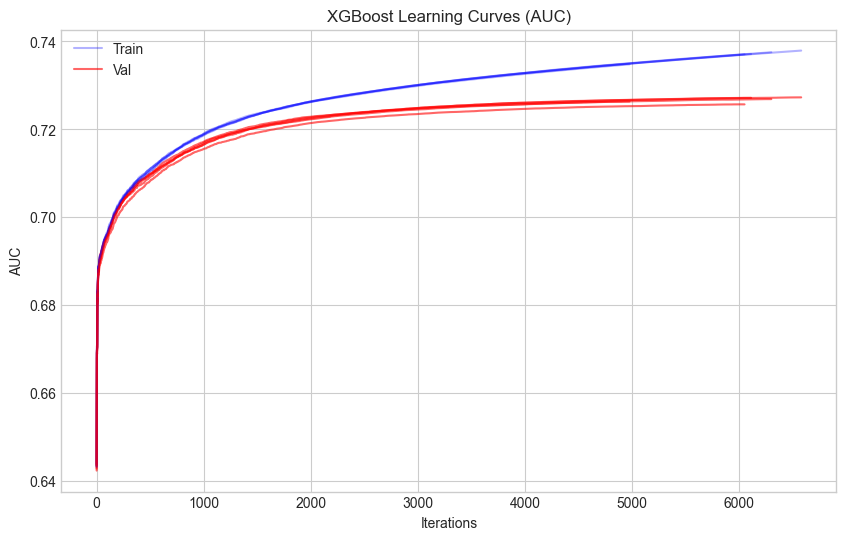

In [22]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results)

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

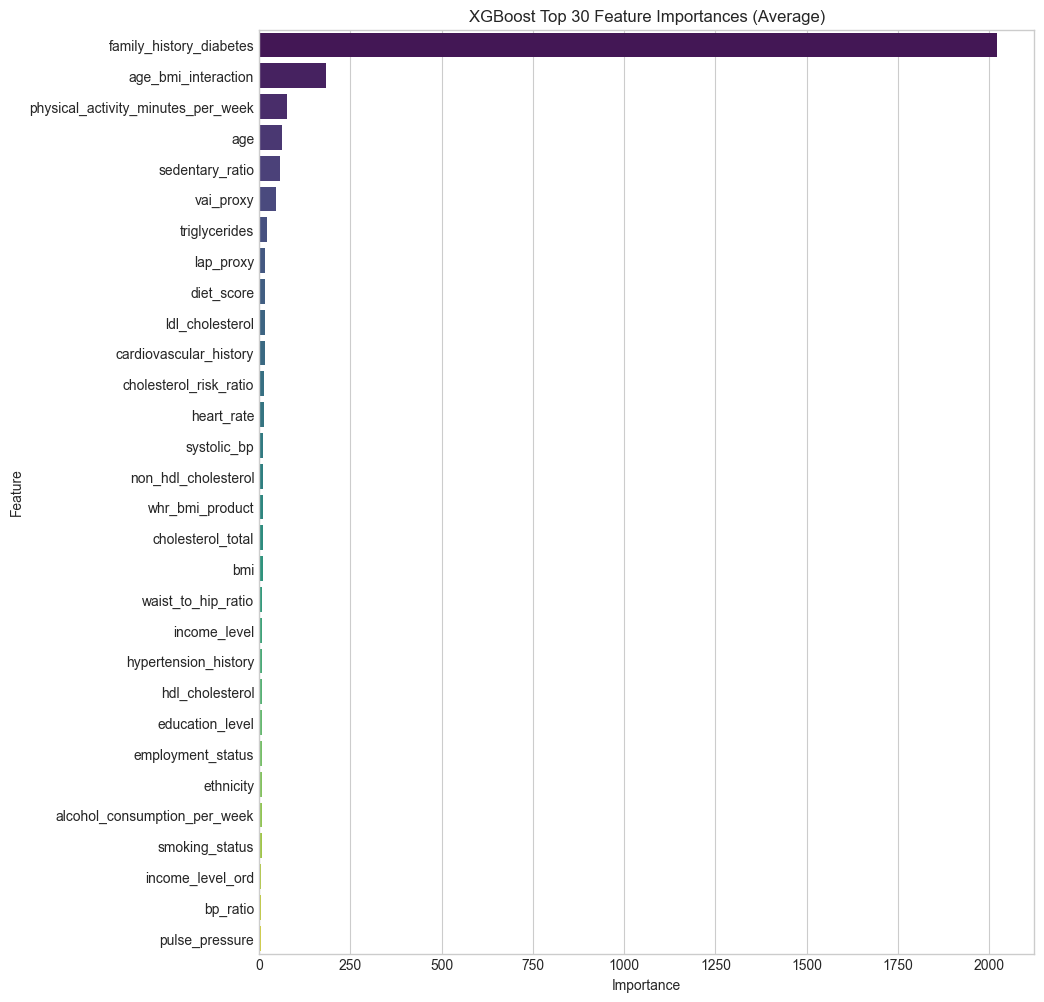

In [23]:
mviz.plot_feature_importance(models, show_values=True)

### ROC Curve (Receiver Operating Characteristic)

A plot of the **True Positive Rate** (Sensitivity) vs. the **False Positive Rate** (1 - Specificity) at every possible probability threshold (0% to 100%).

**Interpretation**  
*   **Top-Left Corner:** The perfect model. It catches 100% of diabetes cases with 0 false alarms.
*   **Diagonal Line:** Random guessing (AUC = 0.5).
*   **The Curve:** Shows the trade-off. To catch more diabetes cases (move up), we inevitably accept more false alarms (move right).
    

**What else can ROC be used for?**  
*   **Threshold Tuning:** The model outputs a probability (e.g., 0.35). Is that a "Yes" or a "No"?
    *   If this is a **Pre-Screening App** (high sensitivity needed), we pick a point high on the Y-axis (e.g., threshold 0.2), accepting that we'll flag some healthy people.
    *   If this is for **Surgery** (high precision needed), we pick a point far left on the X-axis (e.g., threshold 0.8), ensuring we only operate when very certain.
*   **Model Comparison:** In the upcoming "Model Blending/Stacking" notebook, we can plot the curves for XGBoost, CatBoost, and LightGBM on one graph. If the curves cross, one model might be better for high-sensitivity tasks while the other is better for high-precision tasks, even if their AUC is similar.

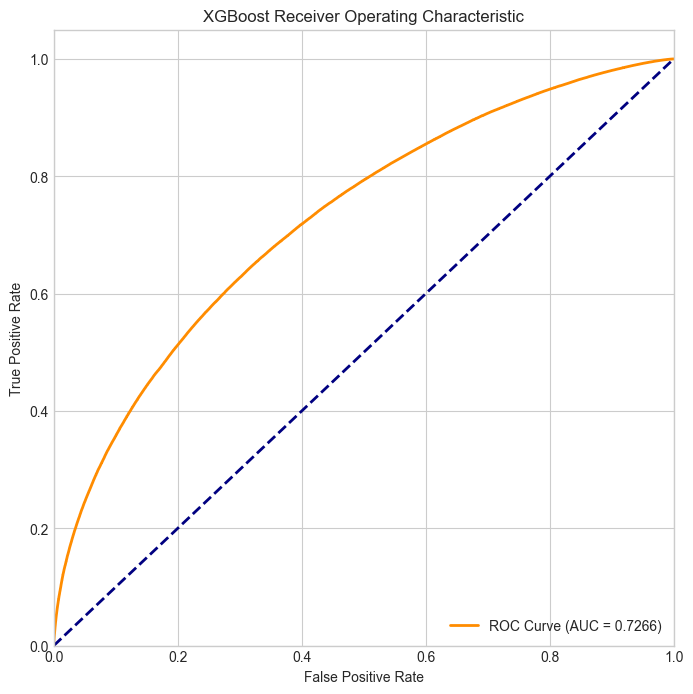

In [24]:
mviz.plot_roc_curve(y, oof_preds)

## Prepare Submission

In [14]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  diagnosed_diabetes
0  700000               0.523
1  700001               0.719
2  700002               0.810
3  700003               0.448
4  700004               0.941
5  700005               0.647
6  700006               0.757
7  700007               0.943
8  700008               0.612
9  700009               0.813


In [15]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [16]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_xgb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/xgb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_xgb': test_preds})
test_pred_df.to_csv(f'{output_dir}/xgb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/xgb_oof_preds.csv, {output_dir}/xgb_test_preds.csv')

Saved for Blending: predictions/xgb_oof_preds.csv, predictions/xgb_test_preds.csv
